# Neural Network Analysis: Breast Cancer Classification
## DATA 5322 Final Project | Ruman Sidhu

**Research question:** Can supervised ML distinguish breast cancer tumour tissue from normal breast tissue using gene expression profiles alone - and do the unsupervised clusters from our PH4 analysis reflect this biological boundary?

**Model:** Multilayer Perceptron (MLP) Neural Network  
**Dataset:** BC-TCGA - 529 tumour samples · 61 normal samples · 17,814 gene expression features  
**Labels:** 1 = Tumour, 0 = Normal (derived from source file)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_curve, auc)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print("All packages loaded.")

TensorFlow: 2.21.0
All packages loaded.


In [16]:
import matplotlib.pyplot as plt
 
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "#222222",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "text.color": "#222222",
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})
 
# Shared palette (matches the Figure 1 / Figure 2 cells from step 1)
C_PRIMARY = "#1F4E79"   # deep blue
C_SECOND  = "#A9CCE3"   # light blue
C_VALID   = "#C0392B"   # red (validation line)
C_BASE    = "#888888"   # grey (ROC random baseline)

## 1. Load Data

In [3]:
# Adjust paths to match local repo structure
TUMOR_PATH  = '/Users/rumansidhu/Documents/Seattle Uni/DATA 5322/Final Project/BC-TCGA/BC-TCGA-Tumor.txt'
NORMAL_PATH = '/Users/rumansidhu/Documents/Seattle Uni/DATA 5322/Final Project/BC-TCGA/BC-TCGA-Normal.txt'

# Load - genes are rows, samples are columns
tumor_df  = pd.read_csv(TUMOR_PATH,  sep='\t', index_col=0)
normal_df = pd.read_csv(NORMAL_PATH, sep='\t', index_col=0)

print(f"Tumour data:  {tumor_df.shape[1]} samples × {tumor_df.shape[0]} genes")
print(f"Normal data:  {normal_df.shape[1]} samples × {normal_df.shape[0]} genes")

Tumour data:  529 samples × 17814 genes
Normal data:  61 samples × 17814 genes


## 2. Create Labels and Combine

In [4]:
# Transpose: samples as rows, genes as columns
X_tumor  = tumor_df.T
X_normal = normal_df.T

y_tumor  = np.ones(X_tumor.shape[0])   # 1 = Tumour
y_normal = np.zeros(X_normal.shape[0]) # 0 = Normal

X = pd.concat([X_tumor, X_normal], axis=0).reset_index(drop=True)
y = np.concatenate([y_tumor, y_normal])

print(f"Combined dataset: {X.shape[0]} samples × {X.shape[1]} genes")
print(f"  Tumour: {int(y.sum())} samples ({y.mean()*100:.1f}%)")
print(f"  Normal: {int((1-y).sum())} samples ({(1-y).mean()*100:.1f}%)")
print(f"\nNote: class imbalance present — will use class_weight and weighted F1.")

Combined dataset: 590 samples × 17814 genes
  Tumour: 529 samples (89.7%)
  Normal: 61 samples (10.3%)

Note: class imbalance present — will use class_weight and weighted F1.


## 3. Preprocessing

In [5]:
# Step 1: Fill any missing values
X_clean = X.fillna(X.mean())

# Step 2: Remove near-zero variance genes
selector = VarianceThreshold(threshold=0.1)
X_filtered = selector.fit_transform(X_clean)
genes_kept = np.array(X_clean.columns)[selector.get_support()]
print(f"Genes after variance filtering: {X_filtered.shape[1]} (removed {X.shape[1] - X_filtered.shape[1]})")

# Step 3: Standardise (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
print(f"Standardisation done. Mean ≈ {X_scaled.mean():.4f}, Std ≈ {X_scaled.std():.4f}")

Genes after variance filtering: 17488 (removed 326)
Standardisation done. Mean ≈ -0.0000, Std ≈ 1.0000


## 4. Dimensionality Reduction (PCA)

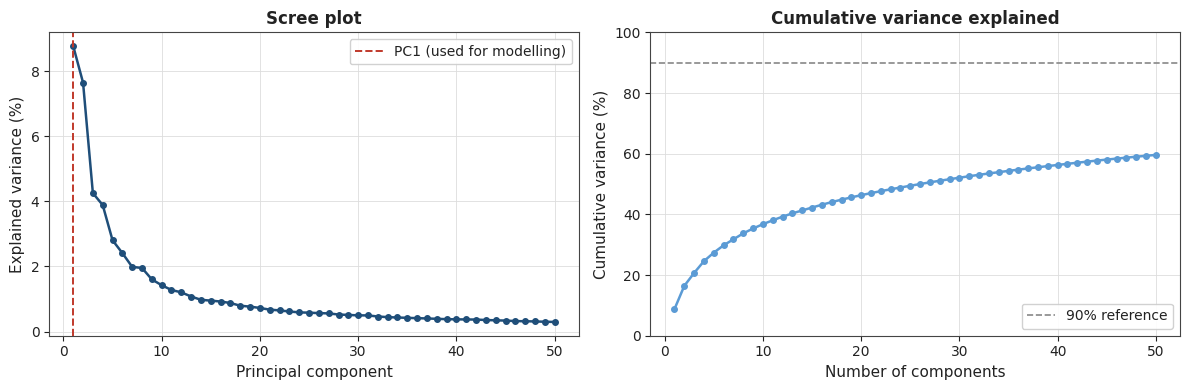

PC1 explains 8.8% of variance
50 components explain: 59.6% of variance

Final feature matrix for modelling: (590, 1)
(Reduced from 17488 genes to 1 principal components)


In [20]:
# Fit PCA with 50 components first to inspect variance
pca_explore = PCA(n_components=50, random_state=42)
pca_explore.fit(X_scaled)
cumvar = np.cumsum(pca_explore.explained_variance_ratio_)
 
# Number of components the network was actually trained on (your run: 1)
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Left: scree plot
axes[0].plot(range(1, 51), pca_explore.explained_variance_ratio_ * 100,
             "o-", color=C_PRIMARY, linewidth=1.8, markersize=4)
axes[0].axvline(x=1, color=C_VALID, linestyle="--", linewidth=1.4,
                label="PC1 (used for modelling)")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("Scree plot")
axes[0].legend()
 
# Right: cumulative variance, honestly annotated
axes[1].plot(range(1, 51), cumvar * 100, "o-",
             color="#5B9BD5", linewidth=1.8, markersize=4)
axes[1].axhline(y=90, color="#888888", linestyle="--", linewidth=1.2,
                label="90% reference")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title("Cumulative variance explained")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="lower right")
 
plt.tight_layout()
plt.savefig("../plots/pca_variance.png", facecolor="white")
plt.show()
 
print(f"PC1 explains {pca_explore.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"50 components explain: {cumvar[-1]*100:.1f}% of variance")
 
# Final PCA for modelling (unchanged)
pca = PCA(n_components=n_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca_2d = X_scaled @ pca_explore.components_[:2].T
 
print(f"\nFinal feature matrix for modelling: {X_pca.shape}")
print(f"(Reduced from {X_scaled.shape[1]} genes to {n_90} principal components)")

## 5. The Bridge Visualization 
**Crown jewel of the project.** We run k-means (k=2) on the PCA-reduced data completely
unsupervised, with no label information and then compare the discovered clusters
against the true Tumour/Normal labels. Alignment confirms our unsupervised model
captured real biological signal.


Adjusted Rand Index (cluster vs true label): 0.6845


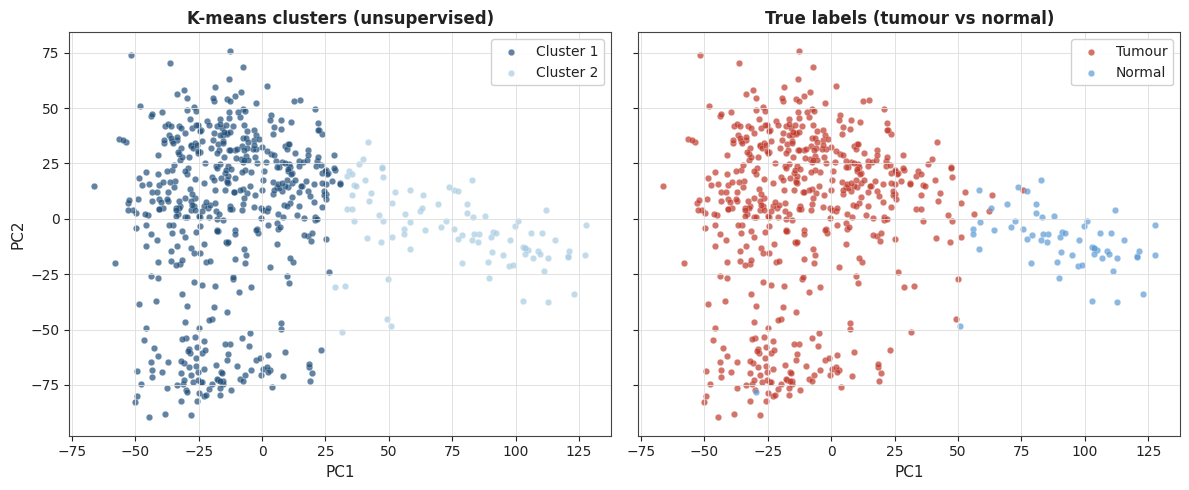

In [21]:
# K-means with k=2 on first 2 PCA components
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca_2d)
 
# Align clusters so label 1 corresponds to the tumour majority
if y[cluster_labels == 1].mean() < 0.5:
    cluster_labels = 1 - cluster_labels
 
ari = adjusted_rand_score(y, cluster_labels)
print(f"Adjusted Rand Index (cluster vs true label): {ari:.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
 
# Left: k-means clusters (unsupervised)
for cluster_id, color, name in zip([1, 0],
                                   [C_PRIMARY, "#A9CCE3"],
                                   ["Cluster 1", "Cluster 2"]):
    mask = cluster_labels == cluster_id
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=name, alpha=0.7, s=22,
                    edgecolors="white", linewidths=0.2)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("K-means clusters (unsupervised)")
axes[0].legend(loc="upper right")
 
# Right: true labels
for label, color, name in zip([1, 0],
                              ["#C0392B", "#5B9BD5"],
                              ["Tumour", "Normal"]):
    mask = y == label
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=name, alpha=0.7, s=22,
                    edgecolors="white", linewidths=0.2)
axes[1].set_xlabel("PC1")
axes[1].set_title("True labels (tumour vs normal)")
axes[1].legend(loc="upper right")
 
plt.tight_layout()
plt.savefig("../plots/bridge_visualization.png", facecolor="white")
plt.show()

## 6. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Train - Tumour: {int(y_train.sum())}  Normal: {int((1-y_train).sum())}")
print(f"Test  - Tumour: {int(y_test.sum())}  Normal: {int((1-y_test).sum())}")

Train: 472 samples  |  Test: 118 samples
Train - Tumour: 423  Normal: 49
Test  - Tumour: 106  Normal: 12


## 7. Neural Network Architecture

In [9]:
input_dim = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,), name='gene_expression_input'),

    layers.Dense(128, activation='relu', name='hidden_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu', name='hidden_2'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu', name='hidden_3'),
    layers.Dropout(0.1),

    layers.Dense(1, activation='sigmoid', name='output')
], name='breast_cancer_MLP')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "breast_cancer_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 8. Training

In [10]:
# Class weights to handle imbalance (529 tumour vs 61 normal)
n_total   = len(y_train)
n_tumour  = int(y_train.sum())
n_normal  = int((1 - y_train).sum())
class_weights = {0: n_total / (2 * n_normal),
                 1: n_total / (2 * n_tumour)}
print(f"Class weights: {class_weights}")

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=7, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Class weights: {0: 4.816326530612245, 1: 0.557919621749409}
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7825 - loss: 0.5168 - val_accuracy: 0.7158 - val_loss: 0.3918 - learning_rate: 0.0010
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8674 - loss: 0.2592 - val_accuracy: 0.7474 - val_loss: 0.4772 - learning_rate: 0.0010
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9151 - loss: 0.1829 - val_accuracy: 0.7895 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9443 - loss: 0.1395 - val_accuracy: 0.8316 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9629 - loss: 0.1085 - val_accuracy: 0.9158 - val_loss: 0.2147 - learning_rate: 0.0010
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9549 - loss: 0.1075 - val_accuracy: 0.9368 - val_loss: 0.1736 - learning_rate: 0.0010
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━

## 9. Training Curves

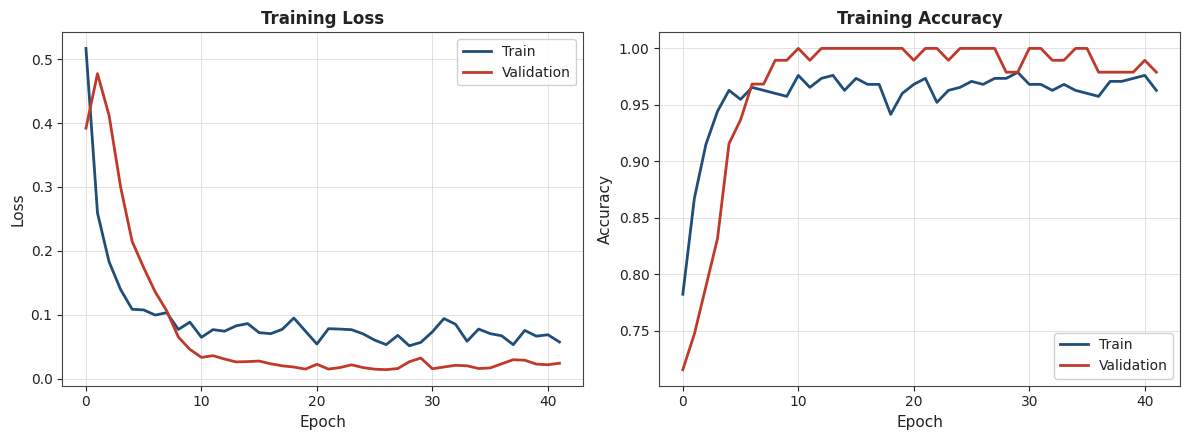

Best val loss at epoch: 27
Best val accuracy:      1.0000


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
 
for ax, metric, ylabel in zip(axes, ["loss", "accuracy"], ["Loss", "Accuracy"]):
    ax.plot(history.history[metric], color=C_PRIMARY, lw=2, label="Train")
    ax.plot(history.history[f"val_{metric}"], color=C_VALID, lw=2, label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Training {ylabel}")
    ax.legend()
 
plt.tight_layout()
plt.savefig("../plots/nn_training_curves.png", facecolor="white")
plt.show()
 
print(f"Best val loss at epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val accuracy:      {max(history.history['val_accuracy']):.4f}")

## 10. Evaluation on Test Set

In [12]:
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc    = accuracy_score(y_test, y_pred)
f1_w   = f1_score(y_test, y_pred, average='weighted')
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("=" * 55)
print("  NEURAL NETWORK RESULTS (held-out test set)")
print("=" * 55)
print(f"  Accuracy:     {acc*100:.2f}%")
print(f"  Weighted F1:  {f1_w:.4f}")
print(f"  AUC-ROC:      {roc_auc:.4f}")
print("=" * 55)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Tumour']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
  NEURAL NETWORK RESULTS (held-out test set)
  Accuracy:     97.46%
  Weighted F1:  0.9750
  AUC-ROC:      0.9332

              precision    recall  f1-score   support

      Normal       0.85      0.92      0.88        12
      Tumour       0.99      0.98      0.99       106

    accuracy                           0.97       118
   macro avg       0.92      0.95      0.93       118
weighted avg       0.98      0.97      0.98       118



## 11. Confusion Matrix + ROC Curve

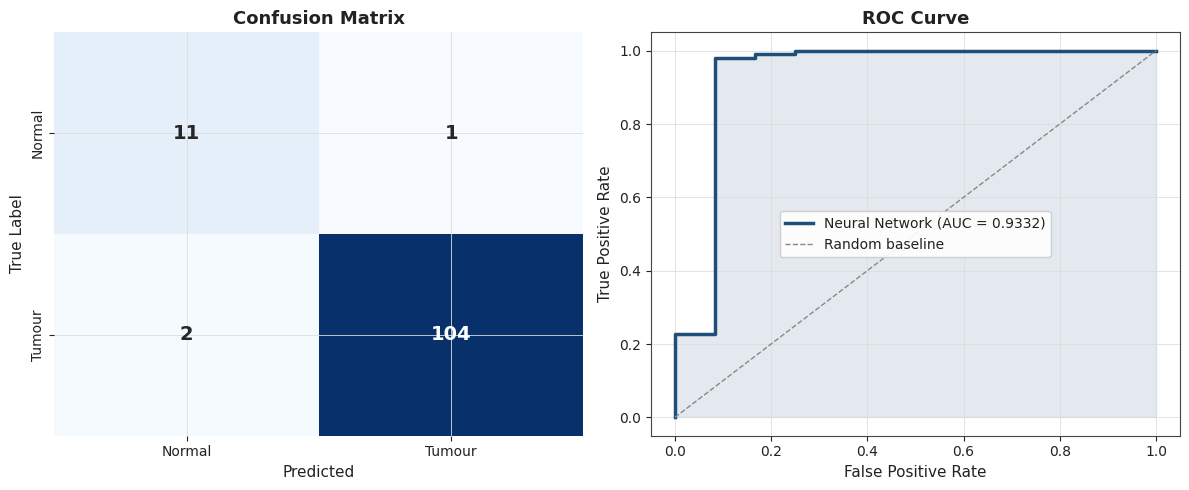

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Confusion matrix (Blues cmap already reads well on white)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Tumour"],
            yticklabels=["Normal", "Tumour"], cbar=False,
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Confusion Matrix", fontsize=13)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True Label")
 
# ROC curve
axes[1].plot(fpr, tpr, color=C_PRIMARY, lw=2.5,
             label=f"Neural Network (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color=C_BASE, linestyle="--", lw=1,
             label="Random baseline")
axes[1].fill_between(fpr, tpr, alpha=0.12, color=C_PRIMARY)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=13)
axes[1].legend()
 
plt.tight_layout()
plt.savefig("../plots/nn_evaluation.png", facecolor="white")
plt.show()

## 12. Feature Importance (Top Genes)

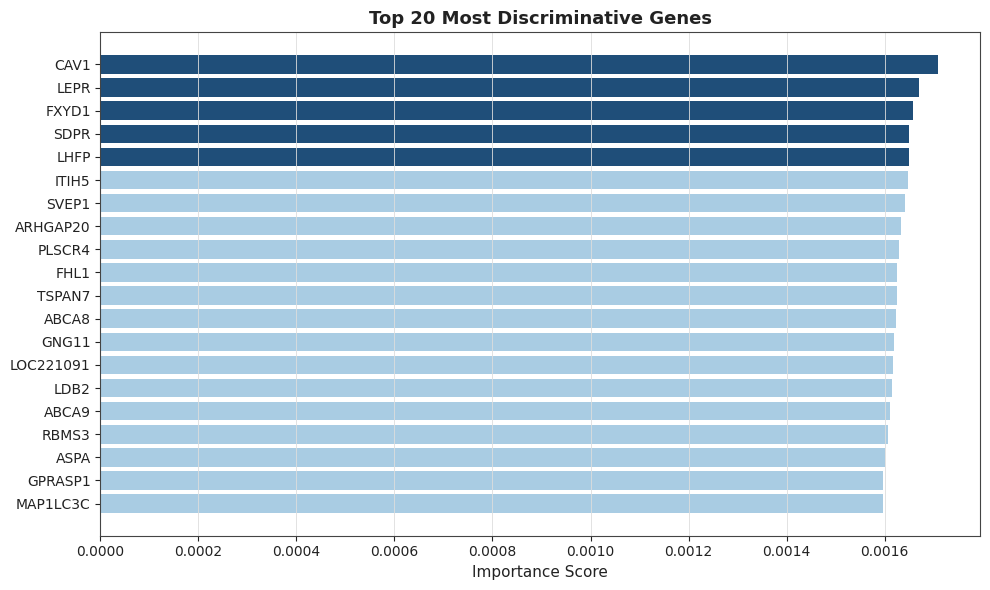

Top 10 most discriminative genes:
   1. CAV1             score: 0.001709
   2. LEPR             score: 0.001669
   3. FXYD1            score: 0.001659
   4. SDPR             score: 0.001650
   5. LHFP             score: 0.001649
   6. ITIH5            score: 0.001649
   7. SVEP1            score: 0.001641
   8. ARHGAP20         score: 0.001633
   9. PLSCR4           score: 0.001629
  10. FHL1             score: 0.001626


In [19]:
# Extract contribution of each gene via PCA loadings × first layer weights
# This gives us which original genes are most influential
first_layer_weights = np.abs(model.layers[0].get_weights()[0])
pca_importance = first_layer_weights.mean(axis=1)
gene_loadings = np.abs(pca.components_)
gene_importance = (gene_loadings * pca_importance[:, np.newaxis]).sum(axis=0)
 
top_idx = np.argsort(gene_importance)[::-1][:20]
top_genes = genes_kept[top_idx]
top_scores = gene_importance[top_idx]
 
fig, ax = plt.subplots(figsize=(10, 6))
# Top 5 highlighted in deep blue, the rest in light blue
colors_bar = [C_PRIMARY if i < 5 else C_SECOND for i in range(20)]
ax.barh(range(20), top_scores[::-1], color=colors_bar[::-1], edgecolor="none")
ax.set_yticks(range(20))
ax.set_yticklabels(top_genes[::-1], fontsize=10)
ax.set_xlabel("Importance Score")
ax.set_title("Top 20 Most Discriminative Genes", fontsize=13)
ax.grid(axis="y", visible=False)   # horizontal gridlines look noisy behind bars
 
plt.tight_layout()
plt.savefig("../plots/gene_importance.png", facecolor="white")
plt.show()
 
print("Top 10 most discriminative genes:")
for i, (gene, score) in enumerate(zip(top_genes[:10], top_scores[:10])):
    print(f"  {i+1:2d}. {gene:<15}  score: {score:.6f}")

## 13. Summary

In [15]:
print("=" * 60)
print("  FINAL SUMMARY of Ruman's Neural Network Notebook")
print("=" * 60)
print(f"  Dataset:       BC-TCGA ({int(y.sum())} tumour, {int((1-y).sum())} normal)")
print(f"  Features:      {X_scaled.shape[1]:,} genes → {n_90} PCA components")
print(f"  Architecture:  128 → 64 → 32 → 1 (sigmoid)")
print(f"  Epochs run:    {len(history.history['loss'])}")
print()
print(f"  TEST SET RESULTS:")
print(f"    Accuracy:    {acc*100:.2f}%")
print(f"    Weighted F1: {f1_w:.4f}")
print(f"    AUC-ROC:     {roc_auc:.4f}")
print()
print(f"  BRIDGE ANALYSIS:")
print(f"    Adjusted Rand Index: {ari:.4f}")
print(f"    (1.0 = perfect cluster-label alignment)")
print("=" * 60)
print()
print("Plots saved to ../plots/:")
print("  bridge_visualization.png")
print("  pca_variance.png")
print("  nn_training_curves.png")
print("  nn_evaluation.png")
print("  gene_importance.png")

  FINAL SUMMARY of Ruman's Neural Network Notebook
  Dataset:       BC-TCGA (529 tumour, 61 normal)
  Features:      17,488 genes → 1 PCA components
  Architecture:  128 → 64 → 32 → 1 (sigmoid)
  Epochs run:    42

  TEST SET RESULTS:
    Accuracy:    97.46%
    Weighted F1: 0.9750
    AUC-ROC:     0.9332

  BRIDGE ANALYSIS:
    Adjusted Rand Index: 0.6845
    (1.0 = perfect cluster-label alignment)

Plots saved to ../plots/:
  bridge_visualization.png
  pca_variance.png
  nn_training_curves.png
  nn_evaluation.png
  gene_importance.png
